In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import pickle
import os
import copy
import h5py
import torch
import pickle

keypoints_coco = {
    0: 'nose',
    1: 'leye',
    2: 'reye',
    3: 'lear',
    4: 'rear',
    5: 'lsho',
    6: 'rsho',
    7: 'lelb',
    8: 'relb',
    9: 'lwri',
    10: 'rwri',
    11: 'lhip',
    12: 'rhip',
    13: 'lkne',
    14: 'rkne',
    15: 'lank',
    16: 'rank'
}

In [26]:
def remove_ca(fname):
    try:
        i = fname.index('ca_')
    except:
        return fname
    fname = fname.replace(fname[i:i+6], '')
    return fname

def plot_one_pose(gts_1, locations_1, mult_1, ix, coco_or_h36m='coco', shift_value_1=None):

    GT_org_1 = gts_1[ix] * mult_1
    pred_org_1 = locations_1[ix] * mult_1
    fname_1 = fnames_1[ix]
    if coco_or_h36m == 'h36m':
        body_edges = np.array([[0,1],[1,2],[2,3],[0,4],[4,5],[5,6],[0,7],[7,8],[8,11],[11,12],[12,13],[8,14],[14,15],[15,16],[8,9],[9,10]])
    else:
        body_edges = ((1, 2), (0, 1), (0, 2), (2, 4), (1, 3), (6, 8), (8, 10), (5, 7), (7, 9), (12, 14), (14, 16), (11, 13),
                (13, 15), (5, 6), (11, 12),
                 (0, 5), (0, 6), (5, 11), (6, 12))
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    to_plot = GT_org_1
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')
        
    to_plot = pred_org_1
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='r')
    for edge in body_edges:
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='r')


    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.view_init(40, 0, 'x')
    

def plot_two_pose(gts_1, locations_1, mult_1, gts_2, locations_2, mult_2, ix, fnames_1, fnames_2, run_name_1, run_name_2, coco_or_h36m='coco',
                 shift_value_1=None, shift_value_2=None):
    # plot both

    GT_org_1 = gts_1[ix] * mult_1
    pred_org_1 = locations_1[ix] * mult_1
    fname_1 = fnames_1[ix]

    GT_org_2 = gts_2[ix] * mult_2
    pred_org_2 = locations_2[ix] * mult_2
    fname_2 = fnames_2[ix]
    
    if coco_or_h36m == 'h36m':
        fname_1 = remove_ca(fname_1)
        fname_2 = remove_ca(fname_2)
        
    
    assert fname_1 == fname_2, '{} and {}'.format(fname_1, fname_2)

    # pred_org_2[:, 0] += 4

    mpjpe_idx_1 = np.sqrt(np.sum((GT_org_1 - pred_org_1)**2, axis=1)).mean()
    mpjpe_idx_2 = np.sqrt(np.sum((GT_org_2 - pred_org_2)**2, axis=1)).mean()
    print('absolute mpjpe for {} {} case ({}): '.format(ix, fname_1, run_name_1), mpjpe_idx_1, ' case ({}):'.format(run_name_2), mpjpe_idx_2, 'cm')

    mpjpe_idx_1 = np.sqrt(np.sum((GT_org_1 - pred_org_1)**2, axis=1))
    mpjpe_idx_2 = np.sqrt(np.sum((GT_org_2 - pred_org_2)**2, axis=1))
    for i, kp in keypoints_coco.items():
        print('{} : \t\t\t\t\t {:.2f} \t\t\t {:.2f}'.format(kp, mpjpe_idx_1[i], mpjpe_idx_2[i]))

    # body_edges = np.array([[0,3],[0,9],[1,0],[0,2],[3,4],[4,5],[9,10],[10,11],[2,6],[2,12],[6,7],[7,8],[12,13],[13,14]])
    if coco_or_h36m == 'h36m':
        body_edges = np.array([[0,1],[1,2],[2,3],[0,4],[4,5],[5,6],[0,7],[7,8],[8,11],[11,12],[12,13],[8,14],[14,15],[15,16],[8,9],[9,10]])
    else:
        body_edges = ((1, 2), (0, 1), (0, 2), (2, 4), (1, 3), (6, 8), (8, 10), (5, 7), (7, 9), (12, 14), (14, 16), (11, 13),
                (13, 15), (5, 6), (11, 12),
                 (0, 5), (0, 6), (5, 11), (6, 12))
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(221, projection='3d')

    ax.set_title('GT')
    to_plot = GT_org_1
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')

    to_plot = GT_org_2
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')

    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
#     ax.set_xlim(x_mean - max_range, x_mean + max_range)
#     ax.set_ylim(y_mean - max_range, y_mean + max_range)
#     ax.set_zlim(z_mean - max_range, z_mean + max_range)
    # ax.view_init(90, 90)
    ax.view_init(40, 0, 'x')


    ############## 1st

    ax = fig.add_subplot(222, projection='3d')

    ax.set_title(run_name_1)
    to_plot = pred_org_1
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='orange')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='r')
    # ax.scatter(*to_plot[RIGHT_HIP], color='r', s=100)
    # ax.scatter(*to_plot[RIGHT_WRIST], color='r', s=100)


    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
    ax.set_xlim(x_mean - max_range, x_mean + max_range)
    ax.set_ylim(y_mean - max_range, y_mean + max_range)
    ax.set_zlim(z_mean - max_range, z_mean + max_range)
    # ax.view_init(elev=30, azim=500)
    # ax.view_init(-140, 0)
    to_plot = GT_org_1
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')

    # ax.scatter(*to_plot[RIGHT_HIP], color='g', s=100)
    # ax.scatter(*to_plot[RIGHT_WRIST], color='g', s=100)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
#     ax.view_init(0, -90)
    ax.view_init(40, 0, 'x')

    ################### 2nd
    ax = fig.add_subplot(224, projection='3d')

    ax.set_title(run_name_2)
    to_plot = pred_org_2
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='orange')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='r')
    # ax.scatter(*to_plot[RIGHT_HIP], color='r', s=100)
    # ax.scatter(*to_plot[RIGHT_WRIST], color='r', s=100)


    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
    ax.set_xlim(x_mean - max_range, x_mean + max_range)
    ax.set_ylim(y_mean - max_range, y_mean + max_range)
    ax.set_zlim(z_mean - max_range, z_mean + max_range)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    # ax.view_init(elev=30, azim=500)
    # ax.view_init(-140, 0)
    to_plot = GT_org_2
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')

    # ax.scatter(*to_plot[RIGHT_HIP], color='g', s=100)
    # ax.scatter(*to_plot[RIGHT_WRIST], color='g', s=100)
    # ax.view_init(90, 90)
    ax.view_init(40, 0, 'x')

    ###################### both

    ax = fig.add_subplot(223, projection='3d')

    ax.set_title('both')
    to_plot = pred_org_1
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='orange')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='r')

    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
    ax.set_xlim(x_mean - max_range, x_mean + max_range)
    ax.set_ylim(y_mean - max_range, y_mean + max_range)
    ax.set_zlim(z_mean - max_range, z_mean + max_range)
    # ax.view_init(elev=30, azim=500)
    # ax.view_init(-140, 0)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    to_plot = pred_org_2
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='grey')
#     ax.view_init(0, 90)
#     ax.view_init(40, 0, 'x')

    plt.tight_layout()
    
    
# Function to plot concentric spheres at a keypoint location
def plot_concentric_spheres(ax, center, radii, colors):
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    for radius, color in zip(radii, colors):
        x = radius * np.cos(u) * np.sin(v) + center[0]
        y = radius * np.sin(u) * np.sin(v) + center[1]
        z = radius * np.cos(v) + center[2]
        ax.plot_surface(x, y, z, color=color, alpha=0.7, edgecolors='k')
    
def plot_save_pose(gts_1, locations_1, mult_1, gts_2, locations_2, mult_2, ix, fnames_1, fnames_2, run_name_1, run_name_2, coco_or_h36m='coco',
                 shift_value_1=None, shift_value_2=None):
    
    GT_org_1 = gts_1[ix] * mult_1
    pred_org_1 = locations_1[ix] * mult_1
    fname_1 = fnames_1[ix]

    GT_org_2 = gts_2[ix] * mult_2
    pred_org_2 = locations_2[ix] * mult_2
    fname_2 = fnames_2[ix]
    
    if coco_or_h36m == 'h36m':
        fname_1 = remove_ca(fname_1)
        fname_2 = remove_ca(fname_2)
        
    
    assert fname_1 == fname_2, '{} and {}'.format(fname_1, fname_2)


    # body_edges = np.array([[0,3],[0,9],[1,0],[0,2],[3,4],[4,5],[9,10],[10,11],[2,6],[2,12],[6,7],[7,8],[12,13],[13,14]])
    if coco_or_h36m == 'h36m':
        body_edges = np.array([[0,1],[1,2],[2,3],[0,4],[4,5],[5,6],[0,7],[7,8],[8,11],[11,12],[12,13],[8,14],[14,15],[15,16],[8,9],[9,10]])
    else:
        body_edges = ((1, 2), (0, 1), (0, 2), (2, 4), (1, 3), (6, 8), (8, 10), (5, 7), (7, 9), (12, 14), (14, 16), (11, 13),
                (13, 15), (5, 6), (11, 12),
                 (0, 5), (0, 6), (5, 11), (6, 12))
        
    # Define radii and colors for the spheres
    radii = [0.2, 0.4, 0.6, 1.2]
    colors = ['red', 'orange', 'blue', 'darkblue']
    
    fig = plt.figure(figsize=(10, 10))
    ########### save figure for manuscript
    ax = fig.add_subplot(111, projection='3d')

#     ax.set_title('both')
    to_plot = pred_org_1
#     ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='orange')
    # Plot spheres for each keypoint
    for point in to_plot:
        plot_concentric_spheres(ax, point, radii, colors)
#     for edge in body_edges:
#         # print(edge)
#         ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='r')

    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
    ax.set_xlim(x_mean - max_range, x_mean + max_range)
    ax.set_ylim(y_mean - max_range, y_mean + max_range)
    ax.set_zlim(z_mean - max_range, z_mean + max_range)
    # ax.view_init(elev=30, azim=500)
    # ax.view_init(-140, 0)
#     ax.set_xlabel('x')
#     ax.set_ylabel('y')
#     ax.set_zlabel('z')
    to_plot = pred_org_2
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='grey')
#     ax.view_init(0, 90)
#     ax.view_init(40, 0, 'x')

    plt.tight_layout()
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    plt.savefig("Colored_Spheres_3D_plot.pdf", format='pdf')
    
    
def plot_three_pose(gts_1, locations_1, mult_1, gts_2, locations_2, mult_2, gts_3, locations_3, mult_3, ix, fnames_1, fnames_2, fnames_3, run_name_1, run_name_2, run_name_3, coco_or_h36m='coco'):
    # plot both

    GT_org_1 = gts_1[ix] * mult_1
    pred_org_1 = locations_1[ix] * mult_1
    fname_1 = fnames_1[ix]

    GT_org_2 = gts_2[ix] * mult_2
    pred_org_2 = locations_2[ix] * mult_2
    fname_2 = fnames_2[ix]
    
    GT_org_3 = gts_3[ix] * mult_3
    pred_org_3 = locations_3[ix] * mult_3
    fname_3 = fnames_3[ix]
    
    fname_1 = remove_ca(fname_1)
    fname_2 = remove_ca(fname_2)
    fname_3 = remove_ca(fname_3)
    
    assert fname_1 == fname_2
    assert fname_1 == fname_3

    # pred_org_2[:, 0] += 4

    mpjpe_idx_1 = np.sqrt(np.sum((GT_org_1 - pred_org_1)**2, axis=1)).mean()
    mpjpe_idx_2 = np.sqrt(np.sum((GT_org_2 - pred_org_2)**2, axis=1)).mean()
    mpjpe_idx_3 = np.sqrt(np.sum((GT_org_3 - pred_org_3)**2, axis=1)).mean()
    print('absolute mpjpe for {} {} \n run ({}): '.format(ix, fname_1, run_name_1), mpjpe_idx_1, \
          ' run ({}):'.format(run_name_2), mpjpe_idx_2, \
          ' run ({}):'.format(run_name_3), mpjpe_idx_3, \
          'cm')

    mpjpe_idx_1 = np.sqrt(np.sum((GT_org_1 - pred_org_1)**2, axis=1))
    mpjpe_idx_2 = np.sqrt(np.sum((GT_org_2 - pred_org_2)**2, axis=1))
    mpjpe_idx_3 = np.sqrt(np.sum((GT_org_3 - pred_org_3)**2, axis=1))
    for i, kp in keypoints_coco.items():
        print('{} : \t\t {:.2f} \t {:.2f} \t {:.2f}'.format(kp, mpjpe_idx_1[i], mpjpe_idx_2[i], mpjpe_idx_3[i]))

    # body_edges = np.array([[0,3],[0,9],[1,0],[0,2],[3,4],[4,5],[9,10],[10,11],[2,6],[2,12],[6,7],[7,8],[12,13],[13,14]])
    if coco_or_h36m == 'h36m':
        body_edges = np.array([[0,1],[1,2],[2,3],[0,4],[4,5],[5,6],[0,7],[7,8],[8,11],[11,12],[12,13],[8,14],[14,15],[15,16],[8,9],[9,10]])
    else:
        body_edges = ((1, 2), (0, 1), (0, 2), (2, 4), (1, 3), (6, 8), (8, 10), (5, 7), (7, 9), (12, 14), (14, 16), (11, 13),
                (13, 15), (5, 6), (11, 12),
                 (0, 5), (0, 6), (5, 11), (6, 12))
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(221, projection='3d')

    ax.set_title('GT')
    to_plot = GT_org_1
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')

    to_plot = GT_org_2
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')

    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
#     ax.set_xlim(x_mean - max_range, x_mean + max_range)
#     ax.set_ylim(y_mean - max_range, y_mean + max_range)
#     ax.set_zlim(z_mean - max_range, z_mean + max_range)
    # ax.view_init(90, 90)
    ax.view_init(40, 0, 'x')


    ############## 1st

    ax = fig.add_subplot(222, projection='3d')

    ax.set_title(run_name_1)
    to_plot = pred_org_1
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='orange')
    for edge in body_edges:
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='r')


    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
    ax.set_xlim(x_mean - max_range, x_mean + max_range)
    ax.set_ylim(y_mean - max_range, y_mean + max_range)
    ax.set_zlim(z_mean - max_range, z_mean + max_range)
    # ax.view_init(elev=30, azim=500)
    # ax.view_init(-140, 0)
    to_plot = GT_org_1
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
#     ax.view_init(0, -90)
    ax.view_init(40, 0, 'x')

    ################### 2nd
    ax = fig.add_subplot(223, projection='3d')

    ax.set_title(run_name_2)
    to_plot = pred_org_2
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='orange')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='r')

    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
    ax.set_xlim(x_mean - max_range, x_mean + max_range)
    ax.set_ylim(y_mean - max_range, y_mean + max_range)
    ax.set_zlim(z_mean - max_range, z_mean + max_range)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    # ax.view_init(elev=30, azim=500)
    # ax.view_init(-140, 0)
    to_plot = GT_org_2
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')

    # ax.view_init(90, 90)
    ax.view_init(40, 0, 'x')

    ###################### both

    ax = fig.add_subplot(224, projection='3d')

    ax.set_title(run_name_3)
    to_plot = pred_org_3
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='orange')
    for edge in body_edges:
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='r')

    max_range = np.array([to_plot[:, 0].max() - to_plot[:, 0].min(), to_plot[:, 1].max() - to_plot[:, 1].min(), to_plot[:, 2].max() - to_plot[:, 2].min()]).max() / 2.0
    x_mean = to_plot[:, 0].mean()
    y_mean = to_plot[:, 1].mean()
    z_mean = to_plot[:, 2].mean()
    ax.set_xlim(x_mean - max_range, x_mean + max_range)
    ax.set_ylim(y_mean - max_range, y_mean + max_range)
    ax.set_zlim(z_mean - max_range, z_mean + max_range)
    ax.set_xlabel('x')
    ax.set_xlabel('y')
    ax.set_xlabel('z')
    # ax.view_init(elev=30, azim=500)
    # ax.view_init(-140, 0)
    to_plot = GT_org_3
    ax.scatter(to_plot[:, 0], to_plot[:, 1], to_plot[:, 2], marker='o', s=20, c='b')
    for edge in body_edges:
        # print(edge)
        ax.plot(to_plot[edge,0], to_plot[edge,1], to_plot[edge,2], color='g')

    # ax.view_init(90, 90)
    ax.view_init(40, 0, 'x')

    plt.tight_layout()

    
def print_mpjpe_cals(gts_1, locations_1, mult_1, gts_2, locations_2, mult_2, ix, fnames_1, fnames_2, run_name_1, run_name_2):
    gts_1_nans = gts_1.copy()
    gts_1_nans[gts_1==0] = np.nan

    gts_2_nans = gts_2.copy()
    gts_2_nans[gts_1==0] = np.nan

    # mpjpe_abs_1 = np.sqrt(np.sum((gts_1 - locations_1)**2, axis=2)).mean()
    mpjpe_abs_1 = np.sqrt(np.nansum((gts_1_nans - locations_1)**2, axis=2)).mean()
    # mpjpe_abs_2 = np.sqrt(np.sum((gts_2 - locations_2)**2, axis=2)).mean()
    mpjpe_abs_2 = np.sqrt(np.nansum((gts_2_nans - locations_2)**2, axis=2)).mean()
    print('absolute mpjpe: ({})'.format(run_name_1), mpjpe_abs_1 * mult_1, '\t\t ({})'.format(run_name_2), mpjpe_abs_2 * mult_2)
    
    mpjpe_abs_1_nf = np.sqrt(np.nansum((gts_1_nans - locations_1)**2, axis=2))[:,5:].mean()
    mpjpe_abs_2_nf = np.sqrt(np.nansum((gts_2_nans - locations_2)**2, axis=2))[:,5:].mean()
    print('absolute mpjpe (no face): ({})'.format(run_name_1), mpjpe_abs_1_nf * mult_1, '\t\t ({})'.format(run_name_2), mpjpe_abs_2_nf * mult_2)
    
    mpjpe_idx_1 = np.sqrt(np.sum((gts_1_nans - locations_1)**2, axis=2)).mean(0)
    mpjpe_idx_2 = np.sqrt(np.sum((gts_2_nans - locations_2)**2, axis=2)).mean(0)
    for i, kp in keypoints_coco.items():
        print('{} : \t\t\t\t\t {:.2f} \t\t\t {:.2f}'.format(kp, mpjpe_idx_1[i] * mult_1, mpjpe_idx_2[i] * mult_2))

    gt_rel_1 = gts_1 - gts_1[:, 0:1, :]    # (num_sample, 17, 3)
    pred_rel_1 = locations_1 - locations_1[:, 0:1, :]  # (num_sample, 17, 3)

    gt_rel_2 = gts_2 - gts_2[:, 0:1, :]    # (num_sample, 17, 3)
    pred_rel_2 = locations_2 - locations_2[:, 0:1, :]  # (num_sample, 17, 3)

    mpjpe_rel_1 = np.sqrt(np.sum((gt_rel_1 - pred_rel_1)**2, axis=2)).mean()
    mpjpe_rel_2 = np.sqrt(np.sum((gt_rel_2 - pred_rel_2)**2, axis=2)).mean()
    print('relative mpjpe: ({})'.format(run_name_1), mpjpe_rel_1 * mult_1, '\t\t ({})'.format(run_name_2), mpjpe_rel_2 * mult_2)

    distance_per_dim_1 = (np.abs(gts_1 - locations_1)).mean(axis=0).mean(axis=0)
    distance_per_dim_2 = (np.abs(gts_2 - locations_2)).mean(axis=0).mean(axis=0)
    print('distance per dim: ({})'.format(run_name_1), distance_per_dim_1 * mult_1)
    print('distance per dim: ({})'.format(run_name_2), distance_per_dim_2 * mult_2)

    mpjpe_all_1 = np.sqrt(np.sum((gts_1 - locations_1)**2, axis=2)).mean(1) * mult_1
    mpjpe_all_2 = np.sqrt(np.sum((gts_2 - locations_2)**2, axis=2)).mean(1) * mult_2
    th = 2
    cases_1_bigger = mpjpe_all_1 > mpjpe_all_2 + th
    cases_2_bigger = mpjpe_all_2 > mpjpe_all_1 + th
    print('number of cases where {} is by far ({} cm on avg) better than {}:'.format(run_name_2, th, run_name_1), cases_1_bigger.sum())
    print('number of cases where {} is by far ({} cm on avg) better than {}:'.format(run_name_1, th, run_name_2), cases_2_bigger.sum())
    
    print('casese {} bigger: {}'.format(run_name_1, np.where(cases_1_bigger)[0]))
    print('casese {} bigger: {}'.format(run_name_2, np.where(cases_2_bigger)[0]))
    

In [76]:

prediction_path_1 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_301_amass_yolo_ConfConcat_3viewsV1V2V3_Seed0_RaySineEncNo_IntersectM_Miss20_ZrTknsNo_FuserRays_RNV0/preds_gt_multiview_openmplposer_rumpl_mmpose_best_dict.pkl'
# prediction_path_1 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_401_amass_yolo11_ConfConcat_3viewsV1V2V3_Seed0_RaySineEncNo_IntersectM_Miss20_ZrTknsNo_FuserRays_RNV0/preds_gt_multiview_openmplposer_rumpl_mmpose_best_dict.pkl'
# prediction_path_1 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_501_amass_rtmos_ConfConcat_3viewsV1V2V3_Seed0_RaySineEncNo_IntersectM_Miss20_ZrTknsNo_FuserRays_RNV0/preds_gt_multiview_openmplposer_rumpl_mmpose_best_dict.pkl'
# prediction_path_1 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_601_amass_yolo_ConfConcat_3viewsV1V2V3_Seed0_RaySineEncNo_IntersectM_Miss20_ZrTknsNo_FuserRays_RNV0/preds_gt_multiview_openmplposer_rumpl_mmpose_best_dict.pkl'
# prediction_path_1 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_701_amass_yolo11_ConfConcat_3viewsV1V2V3_Seed0_RaySineEncNo_IntersectM_Miss20_ZrTknsNo_FuserRays_RNV0/preds_gt_multiview_openmplposer_rumpl_mmpose_best_dict.pkl'
# prediction_path_1 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_801_amass_rtmos_ConfConcat_3viewsV1V2V3_Seed0_RaySineEncNo_IntersectM_Miss20_ZrTknsNo_FuserRays_RNV0/preds_gt_multiview_openmplposer_rumpl_mmpose_best_dict.pkl'

prediction_path_2 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_triangulation_yolo/preds_gt_multiview_openmplposer_rumpl_mmpose_as_pred_dict.pkl'
prediction_path_2 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_triangulation_yolo_antoine/preds_gt_multiview_openmplposer_rumpl_mmpose_as_pred_dict.pkl'
# prediction_path_2 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_triangulation_yolo‍‍11/preds_gt_multiview_openmplposer_rumpl_mmpose_as_pred_dict.pkl'
# prediction_path_2 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_triangulation_rtmos/preds_gt_multiview_openmplposer_rumpl_mmpose_as_pred_dict.pkl'
# prediction_path_2 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_triangulation_yolo8_p3/preds_gt_multiview_openmplposer_rumpl_mmpose_as_pred_dict.pkl'
# prediction_path_2 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_triangulation_yolo‍‍11_p3/preds_gt_multiview_openmplposer_rumpl_mmpose_as_pred_dict.pkl'
# prediction_path_2 = '/globalscratch/users/a/b/abolfazl/MPL_files/output/multiview_amass_rumpl/multiview_rumpl_999/rumpl_triangulation_rtmos_p3/preds_gt_multiview_openmplposer_rumpl_mmpose_as_pred_dict.pkl'

# prediction_path_3 = '/globalscratch/users/a/b/abolfazl/PPT_files/output/multiview_cmu_panoptic/multiview_ppt_999/t_82_triangulationFilterFaultyCases_standard_coco_hrnet_2val_mmpose_2viewsV3V23/preds_gt_multiview_cmu_panoptic_mmpose_as_pred_dict.pkl'


run_name_1 = 'mpl'

run_name_2 = 'tri'
# run_name_3 = 'tri'

mult_1 = 100
mult_2 = 100
mult_3 = 1

with open(prediction_path_1, 'rb') as f:
    predictions_1 = pickle.load(f)
gts_1 = predictions_1['gt']
locations_1 = predictions_1['pred']
fnames_1 = predictions_1['fnames']

with open(prediction_path_2, 'rb') as f:
    predictions_2 = pickle.load(f)
gts_2 = predictions_2['gt']
locations_2 = predictions_2['pred']
fnames_2 = predictions_2['fnames']

fnames_2 = fnames_1

# with open(prediction_path_3, 'rb') as f:
#     predictions_3 = pickle.load(f)
# gts_3 = predictions_3['gt']
# locations_3 = predictions_3['pred']
# fnames_3 = predictions_3['fnames']


absolute mpjpe for 100 rtmo-s_8xb32-600e_coco-640x640_protocol_1_BioMotionLab_NTroje_269_100_01_02_03 case (mpl):  5.2896056  case (tri): 5.060490475406303 cm
nose : 					 3.73 			 4.85
leye : 					 2.56 			 3.93
reye : 					 2.05 			 3.04
lear : 					 3.02 			 2.94
rear : 					 1.51 			 0.99
lsho : 					 2.98 			 5.49
rsho : 					 2.93 			 4.44
lelb : 					 7.11 			 6.87
relb : 					 2.55 			 2.69
lwri : 					 8.16 			 7.27
rwri : 					 6.35 			 5.12
lhip : 					 8.08 			 9.27
rhip : 					 6.09 			 7.29
lkne : 					 7.21 			 2.98
rkne : 					 8.99 			 5.17
lank : 					 5.70 			 6.53
rank : 					 10.90 			 7.15


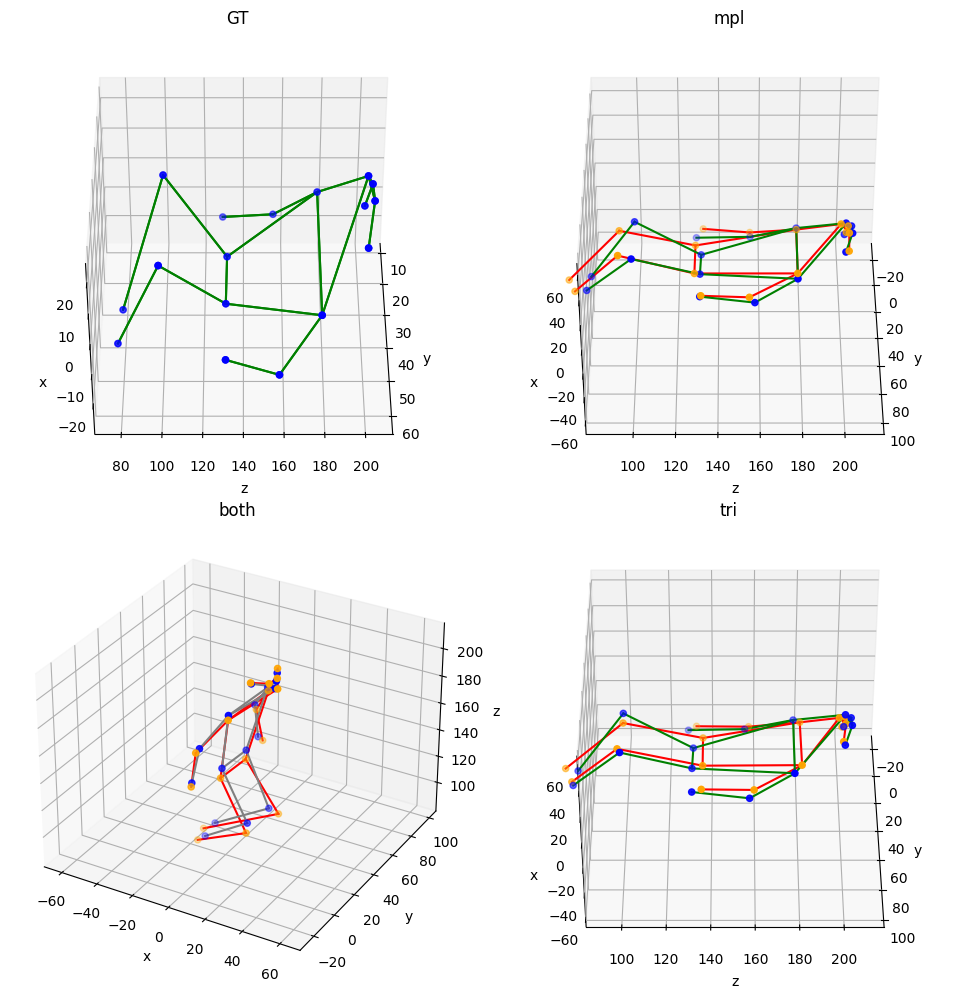

In [74]:
# plot both

ix = 100

plot_two_pose(gts_1, locations_1, mult_1, gts_2, locations_2, mult_2, ix, fnames_1, fnames_2, run_name_1, run_name_2)


In [77]:
print_mpjpe_cals(gts_1, locations_1, mult_1, gts_2, locations_2, mult_2, ix, fnames_1, fnames_2, run_name_1, run_name_2)


absolute mpjpe: (mpl) 8.772922307252884 		 (tri) 166.35507324666128
absolute mpjpe (no face): (mpl) 10.177723318338394 		 (tri) 26.165749490703654
nose : 					 6.22 			 287.84
leye : 					 5.44 			 652.27
reye : 					 5.30 			 634.34
lear : 					 4.89 			 478.29
rear : 					 5.15 			 461.30
lsho : 					 6.77 			 17.08
rsho : 					 7.26 			 17.35
lelb : 					 10.41 			 25.50
relb : 					 10.58 			 22.30
lwri : 					 13.24 			 34.17
rwri : 					 13.12 			 27.48
lhip : 					 6.19 			 16.66
rhip : 					 5.80 			 15.91
lkne : 					 10.19 			 21.50
rkne : 					 10.07 			 23.21
lank : 					 14.34 			 26.59
rank : 					 14.15 			 66.23
relative mpjpe: (mpl) 9.367161989212036 		 (tri) 375.0980245469186
distance per dim: (mpl) [5.7395787 4.025223  2.9566565]
distance per dim: (tri) [135.64491572  68.9798127   34.74960098]
number of cases where tri is by far (2 cm on avg) better than mpl: 599
number of cases where mpl is by far (2 cm on avg) better than tri: 337625
casese mpl bigger: [  5786   63